In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.physics.wigner import wigner_3j, wigner_6j
from scipy import linalg
from sympy import Matrix
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment

In [2]:
#some constants
hbar = 6.62607015*10**-34 / (2*np.pi) # Joules seconds
h = hbar*2*np.pi # J seconds
eps0 = 8.8541878188e-12 
m_e = 9.1093837e-31 #kg
q_e = 1.60217663e-19 #C
a0 = 4*np.pi*eps0*hbar**2/(m_e*q_e**2) # m
u_B = 9.274010e-24 # J/T

In [3]:
def get_L_term(L, F, F_p, M, M_p, J, I, S):
    power_term = (-1)**(J+L+S+1+F_p+J+I+1+F-M)
    sqrt_terms = np.sqrt((2*F+1)*(2*F_p+1))*np.sqrt(L*(L+1)*(2*L+1))
    return power_term*(2*J+1)*sqrt_terms*hbar*wigner_3j(F,1,F_p,-M,0,M_p)*wigner_6j(J,F_p,I,F,J,1)*wigner_6j(L,J,S,J,L,1)

def get_S_term(S, F, F_p, M, M_p, J, I, L):
    power_term = (-1)**(F-M+F_p+J+I+J+S+L+1+1)
    sqrt_terms = np.sqrt((2*F+1)*(2*F_p+1))*np.sqrt((2*J+1)*(2*J+1))*np.sqrt(S*(S+1)*(2*S+1))
    return power_term*sqrt_terms*hbar*wigner_3j(F,1,F_p,-M,0,M_p)*wigner_6j(J,F_p,I,F,J,1)*wigner_6j(S,J,L,J,S,1)

def get_I_term(I, F, F_p, M, M_p, J):
    power_term = (-1)**(F_p+I+J+F-M+1)
    sqrt_terms = np.sqrt((2*F+1)*(2*F_p+1))*np.sqrt(I*(I+1)*(2*I+1))
    return power_term*sqrt_terms*hbar*wigner_3j(F,1,F_p,-M,0,M_p)*wigner_6j(I,F_p,J,F,I,1)

In [4]:
# for a given energy (M, M') in the matrix
def get_matrix_element(M, M_p, F, F_p, I, J, L, S, B, A_hfs, B_hfs):
    hyperfine_element = 0
    K = F*(F+1)-I*(I+1)-J*(J+1)
    if (F == F_p) & (M==M_p):
        hyperfine_element += A_hfs/(hbar**2)*K*hbar**2/2 
        if B_hfs != 0:
            hyperfine_element += B_hfs/(hbar**2)*(3/2*K*(K+1)-2*I*(I+1)*J*(J+1))/(4*I*(2*I-1)*J*(2*J-1))*hbar**2
       
    # Values from Steck (unitless)
    g_L = 0.99999339
    g_S = 2.002319304
    g_I = -0.0009951414

    L_term = -u_B*B/hbar*g_L*get_L_term(L, F, F_p, M, M_p, J, I, S)
    S_term = -u_B*B/hbar*g_S*get_S_term(S, F, F_p, M, M_p, J, I, L)
    I_term = -u_B*B/hbar*g_I*get_I_term(I, F, F_p, M, M_p, J)

    spherical_elements = L_term + S_term + I_term
    return spherical_elements + hyperfine_element

In [5]:
def create_FM_arrays(I,J):
    F_values = np.arange(abs(I-J),I+J+1) # F = |I-J| to |I+J|
    F_array, M_array = [], []
    for F in F_values:
        F_array.extend([F] * int(2*F+1))
        M_array.extend(np.arange(-F, F+1))  # works for both integer and half-integer F
    return np.array(F_array), np.array(M_array)

In [6]:
def get_H(size, Fv, F_pv, Mv, M_pv, I, J, L, S, B_val, A_hfs, B_hfs):
    H = np.zeros((size, size))
    for i in range(0, size):
        for j in range(0, size):
            F, F_p = Fv[i,j], F_pv[i,j]
            M, M_p = Mv[i,j], M_pv[i,j]
            H[i][j] = get_matrix_element(M, M_p, F, F_p, I, J, L, S, B_val, A_hfs, B_hfs)
    return H

In [176]:
def get_Zeeman_shift(state_params):
    A_hfs = state_params['A_hfs']
    B_hfs = state_params['B_hfs']
    B = state_params['B']
    J = state_params['J']
    L = state_params['L']
    I = state_params['I']
    S = state_params['S']

    F, M = create_FM_arrays(I,J)
    size = len(F)
    M_pv, Mv = np.meshgrid(M, M)
    F_pv, Fv = np.meshgrid(F, F)
    #print(M_pv)
    #print(Mv)
    #print(F_pv)
    #print(Fv)

    '''eig_arr = []
    evec_arr = []
    evecs_old = None
    for i in tqdm(range(0, len(B))):
        B_val = B[i]
        H = get_H(size, Fv, F_pv, Mv, M_pv, I, J, L, S, B_val, A_hfs, B_hfs)
        eigenvalues, eigenvectors = linalg.eigh(H)

        if i == 0:
            eig_arr.append(eigenvalues)
            evec_arr.append(eigenvectors)
            evecs_old = np.copy(eigenvectors)
        else:
            overlap = np.abs(evecs_old.T @ eigenvectors)
            cost_matrix = 1 - overlap # 1-|<evecs_old|eigenvectors>|
            _, col_indices = linear_sum_assignment(cost_matrix)

            eig_arr.append(eigenvalues[col_indices])
            evec_arr.append(eigenvectors[:, col_indices])
            evecs_old = eigenvectors[:, col_indices]'''

    
    eig_arr = []
    evec_arr = []
    for i in tqdm(range(0, len(B))):
        B_val = B[i]
        H = get_H(size, Fv, F_pv, Mv, M_pv, I, J, L, S, B_val, A_hfs, B_hfs)
        eigenvalues, eigenvectors = linalg.eigh(H)

        if i == 0:
            eig_arr.append(eigenvalues)
            evec_arr.append(eigenvectors)
        else:
            overlap = np.abs(evec_arr[-1].T @ eigenvectors)
            cost_matrix = 1 - overlap # 1-|<evecs_old|eigenvectors>|
            _, col_indices = linear_sum_assignment(cost_matrix)

            eigenvectors = eigenvectors[:, col_indices]
            eigenvalues = eigenvalues[col_indices]

            for ii in range(len(eigenvectors)):
                if eigenvectors[:,ii] @ evec_arr[-1][:,ii].T < 0:
                    eigenvectors[:,ii] = -eigenvectors[:,ii]

            eig_arr.append(eigenvalues)
            evec_arr.append(eigenvectors)

    return np.array(eig_arr), np.array(evec_arr)

In [167]:
A = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])

#A = np.array([[1,0,0],
              #[0,2,0],
              #[0,0,3]])
eigenvalues, eigenvectors = linalg.eigh(A)

In [168]:
eigenvectors

array([[ 0.80238891,  0.43402538, -0.40962667],
       [ 0.16812656, -0.82296167, -0.54264865],
       [-0.57263033,  0.36654613, -0.73330651]])

In [169]:
eigenvectors[:,[0,2,1]] 

array([[ 0.80238891, -0.40962667,  0.43402538],
       [ 0.16812656, -0.54264865, -0.82296167],
       [-0.57263033, -0.73330651,  0.36654613]])

In [170]:
eigenvectors[[0,2,1]] 

array([[ 0.80238891,  0.43402538, -0.40962667],
       [-0.57263033,  0.36654613, -0.73330651],
       [ 0.16812656, -0.82296167, -0.54264865]])

In [157]:
eigenvectors[:,[0,2,1]] == eigenvectors[[0,2,1]]

array([[ True, False, False],
       [False, False, False],
       [False, False, False]])

In [194]:
#From Steck Rb87 data
def transition_dipole_matrix_element(L,J,Lp,Jp):
    if L==0 and J==1/2 and Lp==1 and Jp== 3/2:
        return 4.227 #*q_e*a0 #table 7
        # 3.58424(52) × 10**(−29) # C m
    elif L==0 and J==1/2 and Lp==1 and Jp== 1/2:
        return 2.992 #*q_e*a0 #table 7
        # 2.5377(12) × 10**(−29) # C m
    else:
        raise ValueError("Don't know this matrix element")

#from eq 2.78 of Nick Hutzler's 137a notes
def no_B_matrix_element(L,J,F,M,q,Lp,Jp,Fp,Mp):
    #assumptions for Rb87
    I = 3/2
    Ip= I
    S = 1/2
    Sp = S

    parity = (-1)**(F + Fp + J + Jp + Ip + L + Sp - M)
    mere_integral = transition_dipole_matrix_element(L,J,Lp,Jp)
    wigner_eckart = wigner_3j(F,1,Fp,-M,q,Mp) #2.75
    first_spectator = ((2*F+1)*(2*Fp+1))**(1/2)*wigner_6j(Jp,Fp,I,F,J,1) #2.76
    second_spectator = ((2*J+1)*(2*Jp+1))**(1/2)*wigner_6j(Lp,Jp,S,J,L,1) #2.77

    # Test (using Steck)
    '''    parity = (-1)**(Fp+M-1+Fp+J+1+I)
    mere_integral = transition_dipole_matrix_element(L,J,Lp,Jp)
    wigner_eckart = wigner_3j(Fp,1,F,Mp,q,-M) #2.75
    first_spectator = ((2*F+1)*(2*Fp+1))**(1/2)*wigner_6j(J,Jp,1,Fp,F,I) #2.76
    second_spectator = (2*J+1)**(1/2)'''

    return parity*mere_integral*wigner_eckart*first_spectator*second_spectator

$$\ket{g}=\ket{n=5,S=\frac{1}{2},L=0,J=\frac{1}{2},I=\frac{3}{2},F=1,m_F=-1}$$
$$\ket{s}=\ket{n=5,S=\frac{1}{2},L=0,J=\frac{1}{2},I=\frac{3}{2},F=2,m_F=1}$$
$$\ket{e}=\ket{n=5,S=\frac{1}{2},L=1,J=\frac{3}{2},I=\frac{3}{2},F=2,m_F=0}$$

In [140]:
#inputs: transition from an S state to a P state and a B field strength
# |L=0,J=1/2,F,M> -> |L=1,J,F,M> , B
# Calculate the eigenvectors under the given magnetic field
# The total transition strength is the double sum over all the transition strengths between the unperturbed eigenstates,
# weighted by the coefficients
# for now we are going to pass the B field strength as an index due to the way the big arrays are constructed

B = np.linspace(0, 1000/10000, 200)

S_12 = {
    'J': 1/2,
    'L': 0,
    'A_hfs': h*3.417341e9, # J
    'B_hfs': 0, # J
    'g_J': 2.00233113,
    'g_I': -0.0009951414,
    'B': B, # T, for ground state 5S_1/2
    'I': 3/2,
    'S': 1/2,
}

# 5²P₁/₂ D1 excited state parameters
P_12 = {
    'J': 1/2,
    'L': 1,
    'A_hfs': h*407.25e6,  # J
    'B_hfs': 0, # J
    'g_J': 0.666,
    'g_I': -0.0009951414,
    'B': B, # T, for excited state 5P_1/2
    'I': 3/2,
    'S': 1/2,
}

# 5²P₃/₂ D2 excited state parameters
P_32 = {
    'J': 3/2,
    'L': 1,
    'A_hfs': h*84.7185e6, # J
    'g_J': 1.3362,
    'g_I': -0.0009951414,
    'B': B, # T, for excited state 5P_3/2
    'B_hfs': h*12.4965e6, # J, for 2P_3/2, include electric quadrupole term (no longer negligible)
    'I': 3/2,
    'S': 1/2,
}   

In [177]:
# Ground state parameters
g_params = S_12
g_eig_arr, g_evec_arr = get_Zeeman_shift(g_params)
gF, gM = create_FM_arrays(g_params['I'],g_params['J'])

# Excited state state parameters
e_params = P_32
e_eig_arr, e_evec_arr = get_Zeeman_shift(e_params)
eF, eM = create_FM_arrays(e_params['I'],e_params['J'])

100%|██████████| 200/200 [00:27<00:00,  7.23it/s]


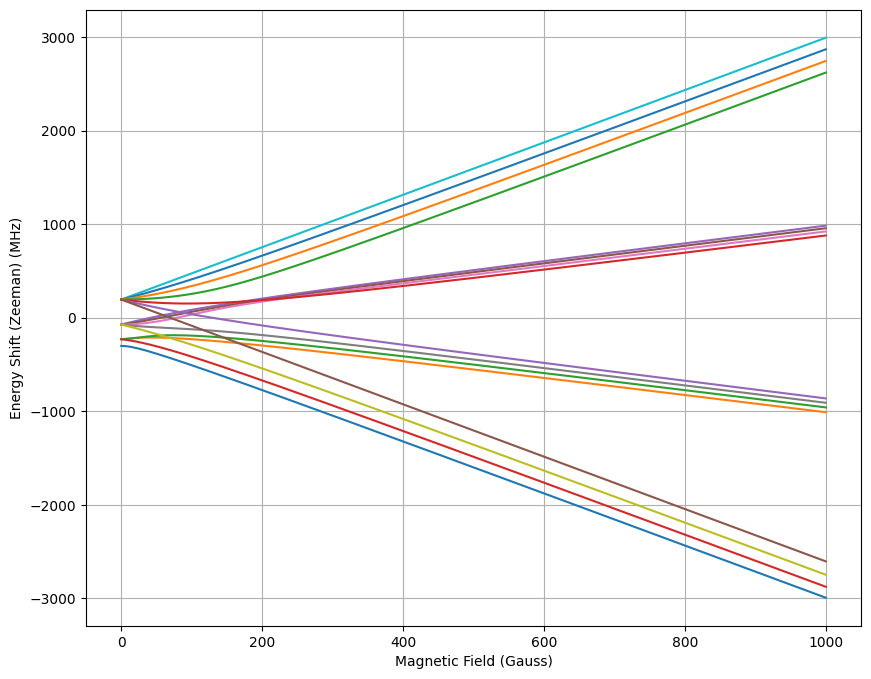

In [178]:
plt.figure(figsize=(10, 8))

color_vec = plt.cm.plasma(np.linspace(1, 0, 4))
                          
for i in range(0, 16):
    plt.plot(B*10000, e_eig_arr[:,i]/h/1e6, '-')

spec = ['S','P','D','F']

plt.xlabel('Magnetic Field (Gauss)')
plt.ylabel('Energy Shift (Zeeman) (MHz)')
plt.grid()

In [179]:
# Converts the F, M arrays into list of tuples
gnums = list(zip(gF,gM))
enums = list(zip(eF,eM))

In [180]:
print(gnums)
print('---')
print(enums)

[(1.0, -1.0), (1.0, 0.0), (1.0, 1.0), (2.0, -2.0), (2.0, -1.0), (2.0, 0.0), (2.0, 1.0), (2.0, 2.0)]
---
[(0.0, -0.0), (1.0, -1.0), (1.0, 0.0), (1.0, 1.0), (2.0, -2.0), (2.0, -1.0), (2.0, 0.0), (2.0, 1.0), (2.0, 2.0), (3.0, -3.0), (3.0, -2.0), (3.0, -1.0), (3.0, 0.0), (3.0, 1.0), (3.0, 2.0), (3.0, 3.0)]


In [181]:
print(gnums[0], enums[11])

(1.0, -1.0) (3.0, -1.0)


In [182]:
# Fills out the transition dipole elements for B=0 
no_B_matrix_element_arr = np.zeros((np.shape(gnums)[0],np.shape(enums)[0]))
L = g_params['L']
J = g_params['J']
Lp = e_params['L']
Jp = e_params['J']
for ii,gnum in enumerate(gnums):
    for jj,enum in enumerate(enums):
        no_B_matrix_element_arr[ii,jj] = no_B_matrix_element(L,J,gnum[0],gnum[1],0,Lp,Jp,enum[0],enum[1])

In [183]:
print(np.shape(no_B_matrix_element_arr))

(8, 16)


In [184]:
e_evec_arr = np.array(e_evec_arr)
g_evec_arr = np.array(g_evec_arr)

In [185]:
# Create a 3D array at each B value for TDMs 
B_matrix_element_arr = np.zeros((np.shape(gnums)[0],np.shape(enums)[0],np.size(B)))
g_innerproduct_arr = np.zeros((np.shape(gnums)[0],np.size(B)))
e_innerproduct_arr = np.zeros((np.shape(enums)[0],np.size(B)))

for ii,gnum in enumerate(gnums):
    g_vecs = g_evec_arr[:,:,ii]
   
    for kk,Bval in enumerate(B):
        if kk != 0:
            g_innerproduct_arr[ii,kk] = g_vecs[kk] @ g_vecs[kk-1].T

for ii,gnum in enumerate(enums):
    e_vecs = e_evec_arr[:,:,ii]
    for kk,Bval in enumerate(B):
            e_innerproduct_arr[ii,kk] = e_vecs[kk] @ e_vecs[kk-1].T


for ii,gnum in enumerate(gnums):
    g_vecs = g_evec_arr[:,:,ii]
    for jj,enum in enumerate(enums):
        e_vecs = e_evec_arr[:,:,jj]
        for kk,Bval in enumerate(B):
            B_matrix_element_arr[ii,jj,kk] = (g_vecs[kk]@no_B_matrix_element_arr@e_vecs[kk])**2 # 1/3 factor from averaging over polarizations
            

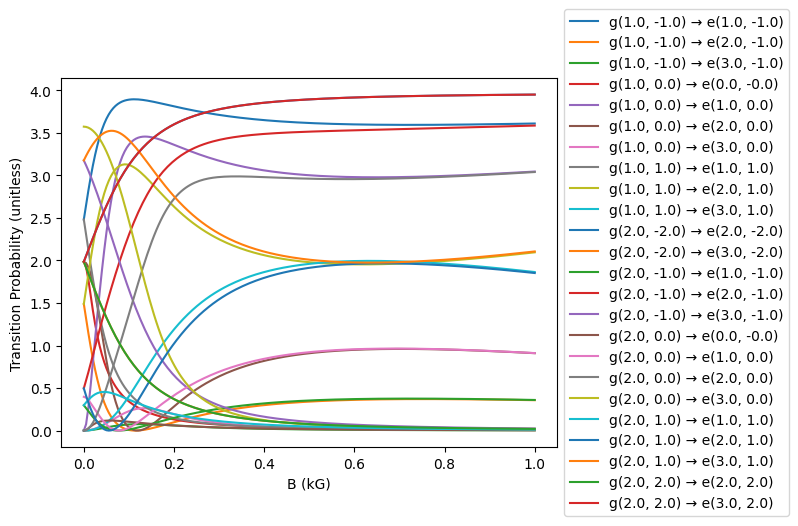

In [186]:
for ii in range(len(gnums)):
    for jj in range(len(enums)):
        # Extract the array along the kk axis (B-field)
        y_values = B_matrix_element_arr[ii, jj, :]
        
        # Plot y vs B
        if y_values.max() > 0.01:  # Only plot if there is a non-zero transition strength
            plt.plot(B*10, y_values, label=f'g{gnums[ii]} → e{enums[jj]}')

plt.xlabel('B (kG)')
plt.ylabel('Transition Probability (unitless)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#plt.ylim([0,0.01])
#plt.xlim([0, 1])

(0.0, 1.0)

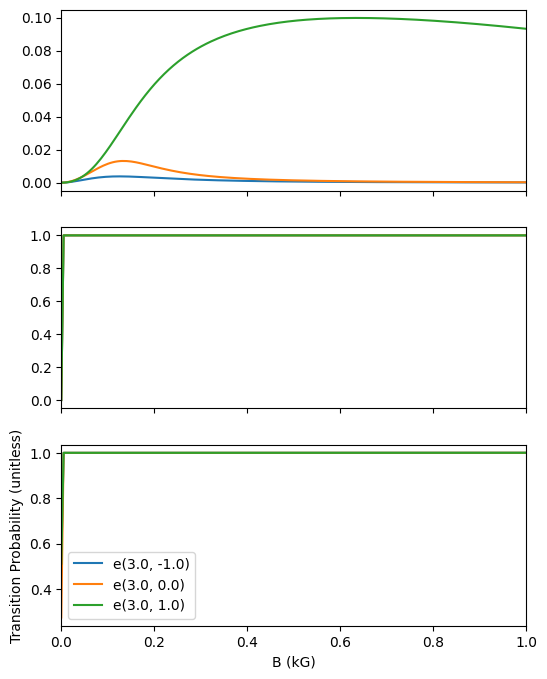

In [200]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

for pp in zip([0,1,2],[11,12,13]):
    # Extract the array along the kk axis (B-field)
    y_values = B_matrix_element_arr[pp[0], pp[1], :]
    
    # Plot y vs B
    if y_values.max() > 0.01:  # Only plot if there is a non-zero transition strength
        axs[0].plot(B*10, y_values/20, label=f'g{gnums[pp[0]]} → e{enums[pp[1]]}')
        axs[1].plot(B*10, g_innerproduct_arr[pp[0], :], label=f'g{gnums[pp[0]]}')
        axs[2].plot(B*10, e_innerproduct_arr[pp[1], :], label=f'e{enums[pp[1]]}')

plt.xlabel('B (kG)')
plt.ylabel('Transition Probability (unitless)')
plt.legend()
plt.xlim([0, 1])

In [188]:
np.shape(B_matrix_element_arr)

(8, 16, 200)

In [189]:
e_vecs = e_evec_arr[:,:,3]

In [190]:
np.shape(e_vecs[2])

(16,)

In [191]:
g_vecs[1]@no_B_matrix_element_arr@e_vecs[4]

1.0484350712501561e-19

In [192]:

np.shape(g_vecs[3])

(8,)

In [193]:
np.shape(no_B_matrix_element_arr)

(8, 16)